In [25]:
#Step 1: Required libraries

import numpy as np
import matplotlib.pyplot as plt

In [26]:
#Step 2: Load ECG signal from TXT file
# Path to your ECG text file

file_path = '/Users/bijitbasumatary/Downloads/ECG DATA/shaurya.txt' # change this to your file name
# Load data (assumes whitespace or tab separated)
data = np.loadtxt(file_path)
# Separate columns
time = data[:, 0]
ecg = data[:, 1]
fs = 1000 # Sampling frequency (Hz)

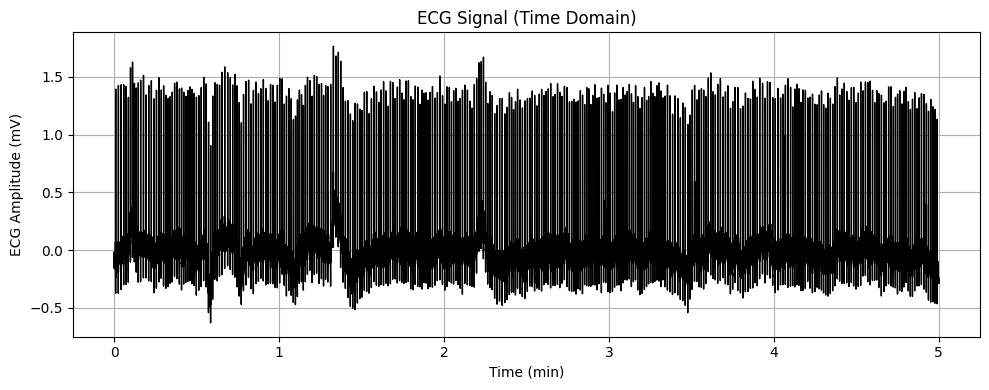

In [27]:
#Step 3: Time-domain visualization

plt.figure(figsize=(10, 4))
plt.plot(time, ecg, color='black', linewidth=1)
plt.xlabel('Time (min)')
plt.ylabel('ECG Amplitude (mV)')
plt.title('ECG Signal (Time Domain)')
plt.grid(True)
plt.tight_layout()
plt.show()

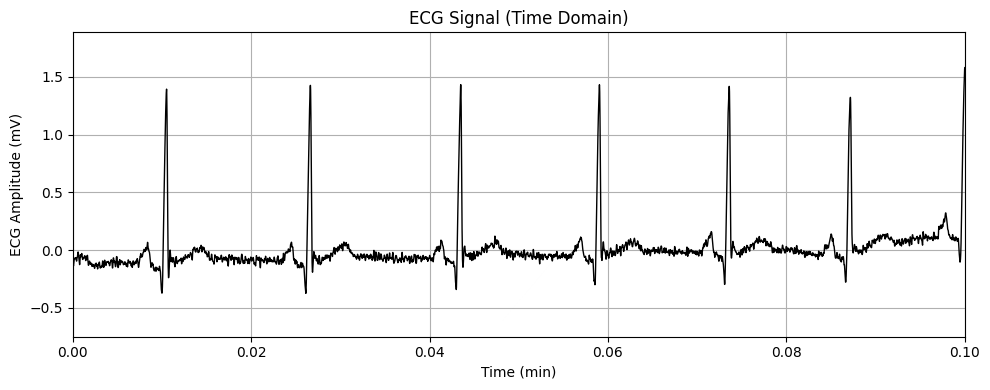

In [31]:
#Step 3: Time-domain visualization (Limit x-axis to 0 - 0.1 s to zoom)

plt.figure(figsize=(10, 4))
plt.plot(time, ecg, color='black', linewidth=1)
plt.xlabel('Time (min)')
plt.ylabel('ECG Amplitude (mV)')
plt.title('ECG Signal (Time Domain)')
plt.xlim([0, 0.1]) # Limit x-axis to 0 - 0.1 s to zoom into waveform details
plt.grid(True)
plt.tight_layout()
plt.show()

In [32]:
#Step 4: Single-sided frequency spectrum (FFT)
# Number of samples
N = len(ecg)

# FFT computation
ecg_fft = np.fft.fft(ecg)    # Compute the FFT of the ECG
freq = np.fft.fftfreq(N, d=1/fs)  # Generate frequency values (in Hz) corresponding to each FFT output sample

# Single-sided spectrum
positive_freqs = freq[:N//2]     # Extract only positive frequency components
fft_magnitude = np.abs(ecg_fft[:N//2]) * 2 / N     # Compute magnitude of FFT and normalize it
                                      # Factor 2 accounts for discarded negative frequencies
                                      # Division by N ensures amplitude normalization

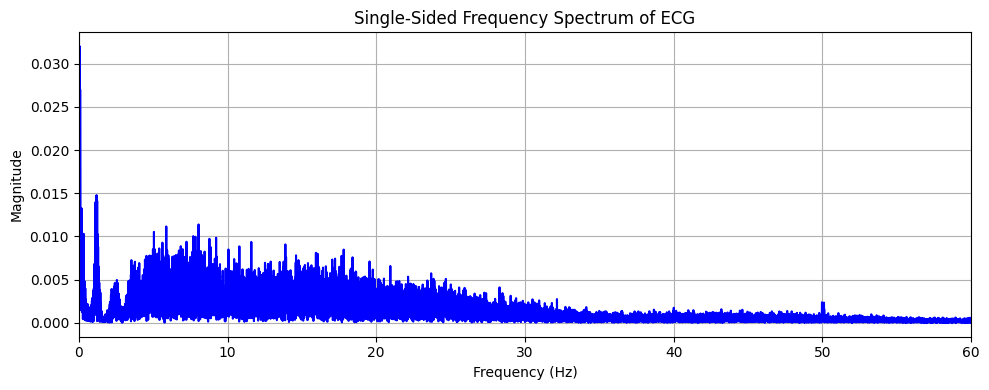

In [33]:
# Step 5: Plot frequency response

plt.figure(figsize=(10, 4))
plt.plot(positive_freqs, fft_magnitude, color='blue')  # Plot FFT magnitude versus positive frequencies
plt.xlabel('Frequency (Hz)')
plt.ylabel('Magnitude')
plt.title('Single-Sided Frequency Spectrum of ECG')
plt.xlim([0, 60])  # ECG energy mostly below 40–50 Hz
plt.grid(True)
plt.tight_layout()
plt.show()

ECG component and Frequency range

P wave	~0.5–5 Hz

QRS complex	~10–25 Hz

T wave	~1–7 Hz

Almost all clinically relevant ECG information lies between 0.5 Hz and 40 Hz.

*Frequencies below 0.5 Hz → Baseline wander

Caused by: Respiration, Electrode movement, Body posture changes

Removed by high-pass cutoff at 0.5 Hz

*Frequencies above 40 Hz → EMG noise

Caused by: Muscle contractions, Patient movement, Tremors

EMG energy is broadband, strongest above 20–30 Hz

Removed by low-pass cutoff at 40 Hz